# Support Vector Machine | Breast Cancer Wisconsin

**Dataset:** Breast Cancer Wisconsin 
**Problem:** Classify tumors as malignant (0) or benign (1) based on 30 cell nucleus measurements.

**Why SVM for this dataset:**
SVM is specifically designed for high-dimensional spaces with relatively few samples -- exactly this dataset (569 samples, 30 features). It works by finding the widest possible margin between classes rather than minimizing a loss function like every other model you have seen. This is a fundamentally different idea.

**Why SVM is different from everything so far:**
- Logistic Regression: finds weights that minimize log loss
- Decision Tree: finds splits that minimize Gini impurity
- SVM: finds the hyperplane that maximizes the margin between the two classes

The margin-maximization approach makes SVM extremely robust in high-dimensional spaces and resistant to overfitting when the margin is large.

**What this notebook covers:**
1. The math -- margin, support vectors, the kernel trick
2. Why feature scaling breaks SVM completely without StandardScaler
3. Linear SVM -- hard margin and soft margin
4. The kernel trick -- RBF, polynomial, sigmoid
5. Hyperparameter tuning -- C and gamma
6. Feature importance via permutation (SVM has no built-in importance)
7. Comparison with logistic regression, decision tree on the same data


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load Dataset

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print()
print("Classes:")
for code, name in enumerate(data.target_names):
    count = (y == code).sum()
    print(f"  {code} = {name:<12} {count} samples ({count/len(y):.1%})")
print()
print("No missing values:", X.isnull().sum().sum())
print()
print("Feature groups (30 total):")
print("  mean_*         -- mean of cell nucleus measurements")
print("  se_* (error)   -- standard error of measurements")
print("  worst_*        -- worst (largest) value of measurements")
print()
print("Each group measures: radius, texture, perimeter, area, smoothness,")
print("compactness, concavity, concave points, symmetry, fractal dimension")

Shape: (569, 30)
Features: 30
Samples: 569

Classes:
  0 = malignant    212 samples (37.3%)
  1 = benign       357 samples (62.7%)

No missing values: 0

Feature groups (30 total):
  mean_*         -- mean of cell nucleus measurements
  se_* (error)   -- standard error of measurements
  worst_*        -- worst (largest) value of measurements

Each group measures: radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension


In [3]:
# Quick look at the data
df_view = X.copy()
df_view['target'] = y
df_view['diagnosis'] = y.map({0: 'malignant', 1: 'benign'})

print("Statistical summary -- first 5 features:")
df_view[list(X.columns[:5]) + ['diagnosis']].groupby('diagnosis').mean().round(3)

Statistical summary -- first 5 features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
diagnosis,,,,,
benign,12.147,17.915,78.075,462.790,0.092
malignant,17.463,21.605,115.365,978.376,0.103


## 2. EDA -- What Separates Malignant from Benign

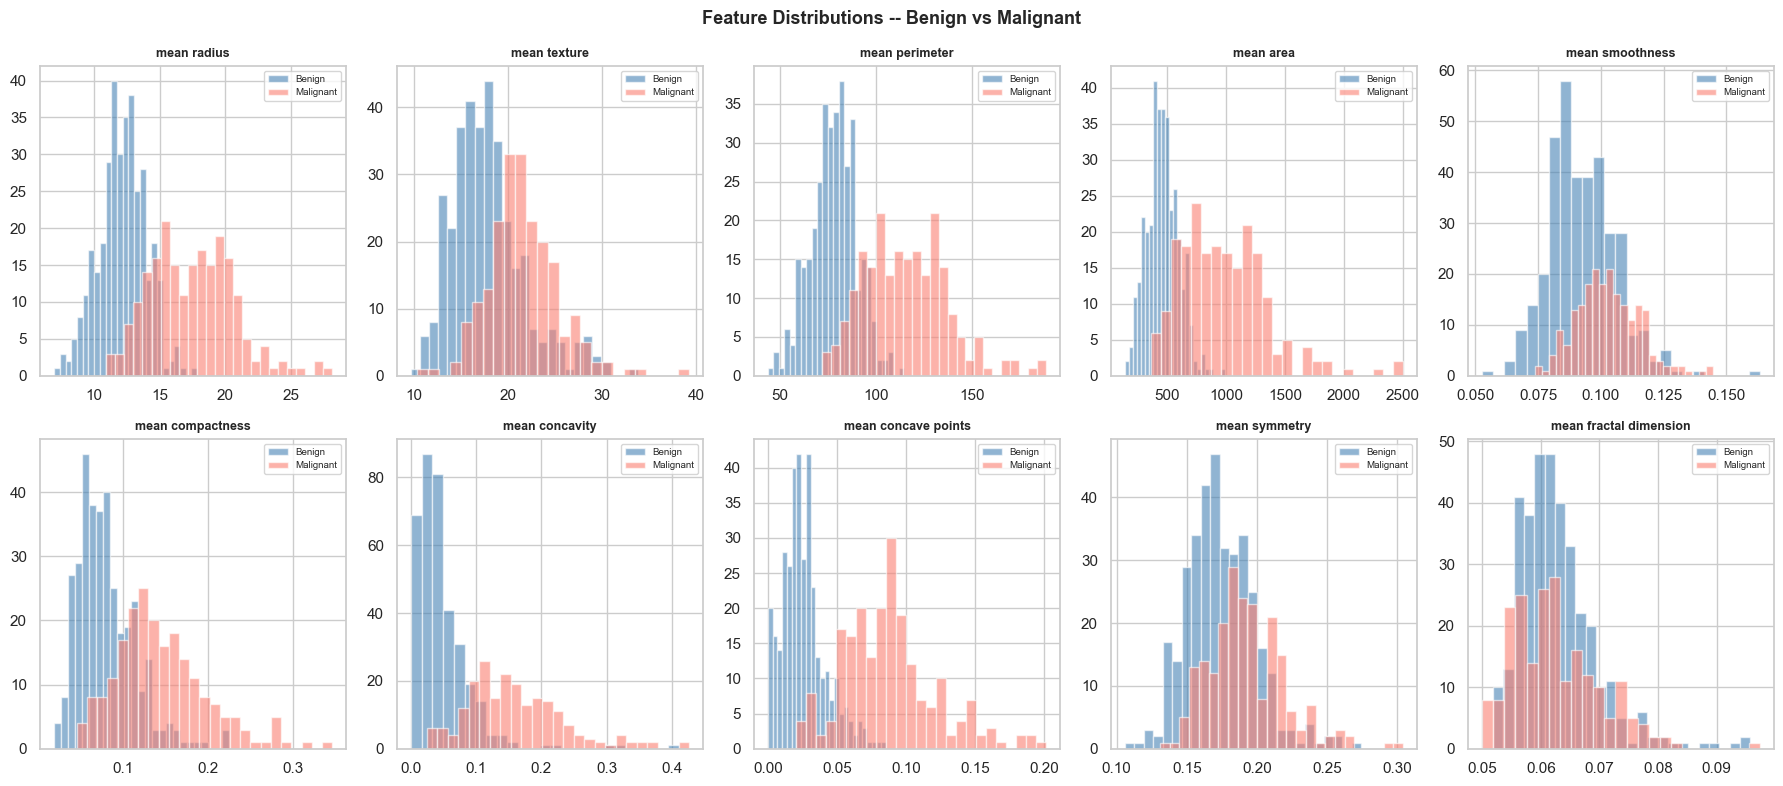

In [5]:
# Feature distributions by class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean compactness', 'mean concavity',
                'mean concave points', 'mean symmetry', 'mean fractal dimension']

for i, feat in enumerate(top_features):
    benign    = X[feat][y == 1]
    malignant = X[feat][y == 0]
    axes[i].hist(benign,    bins=25, alpha=0.6, color='steelblue', label='Benign')
    axes[i].hist(malignant, bins=25, alpha=0.6, color='salmon',    label='Malignant')
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions -- Benign vs Malignant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

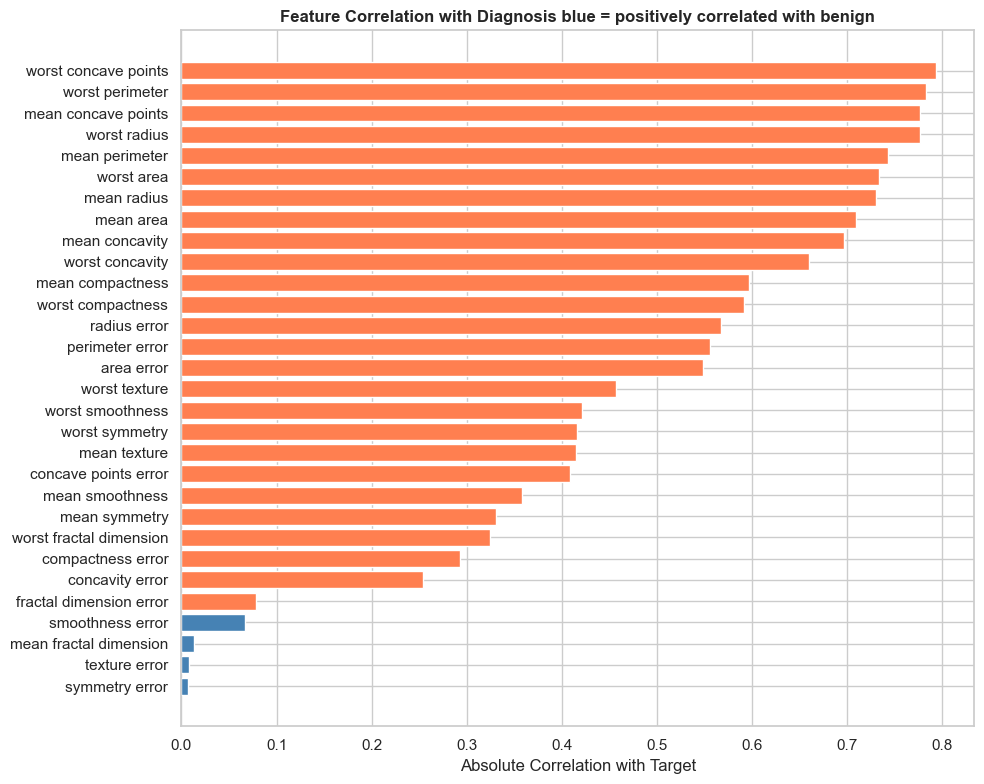

Top 5 most predictive features:
  worst concave points           |r|=0.794  (higher = more malignant)
  worst perimeter                |r|=0.783  (higher = more malignant)
  mean concave points            |r|=0.777  (higher = more malignant)
  worst radius                   |r|=0.776  (higher = more malignant)
  mean perimeter                 |r|=0.743  (higher = more malignant)


In [6]:
# Correlation with target
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['steelblue' if X[feat].corr(y) > 0 else 'coral'
          for feat in corr_with_target.index]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
plt.xlabel('Absolute Correlation with Target')
plt.title('Feature Correlation with Diagnosis blue = positively correlated with benign', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 most predictive features:")
for feat, val in corr_with_target.head(5).items():
    direction = X[feat].corr(y)
    print(f"  {feat:<30} |r|={val:.3f}  ({'higher = more benign' if direction > 0 else 'higher = more malignant'})")

## 3. The Math Behind SVM

**The core idea -- maximum margin:**
Given a dataset that is linearly separable, there are infinitely many hyperplanes that correctly separate the two classes. SVM finds the one that maximizes the margin -- the distance between the hyperplane and the nearest data points from each class.

**Why maximizing the margin matters:**
A larger margin means the model is more confident and more robust to new data points that fall near the boundary. Small-margin classifiers work on training data but generalize poorly.

**Support Vectors:**
The data points that lie exactly on the margin boundary are called support vectors. They are the only points that determine the position of the hyperplane. Remove any non-support-vector point and the hyperplane does not move.

**The optimization problem:**
```
Minimize:    (1/2) ||w||^2
Subject to:  y_i (w . x_i + b) >= 1  for all i
```
Where w is the normal vector to the hyperplane and b is the bias.

**Soft Margin -- parameter C:**
Real data is rarely perfectly separable. The soft margin SVM introduces slack variables that allow some points to be inside the margin or even on the wrong side.

```
C is large  -- small slack allowed -- hard margin -- more overfitting risk
C is small  -- large slack allowed -- soft margin -- more underfitting risk
```

**The Kernel Trick:**
When data is not linearly separable, map it to a higher-dimensional space where it becomes separable. The kernel function computes dot products in that higher-dimensional space without explicitly computing the transformation.

```
Linear kernel:      K(x, z) = x . z
RBF kernel:         K(x, z) = exp(-gamma ||x - z||^2)
Polynomial kernel:  K(x, z) = (x . z + r)^d
```

The RBF kernel effectively maps data into infinite-dimensional space. With the right gamma, almost any boundary can be learned.


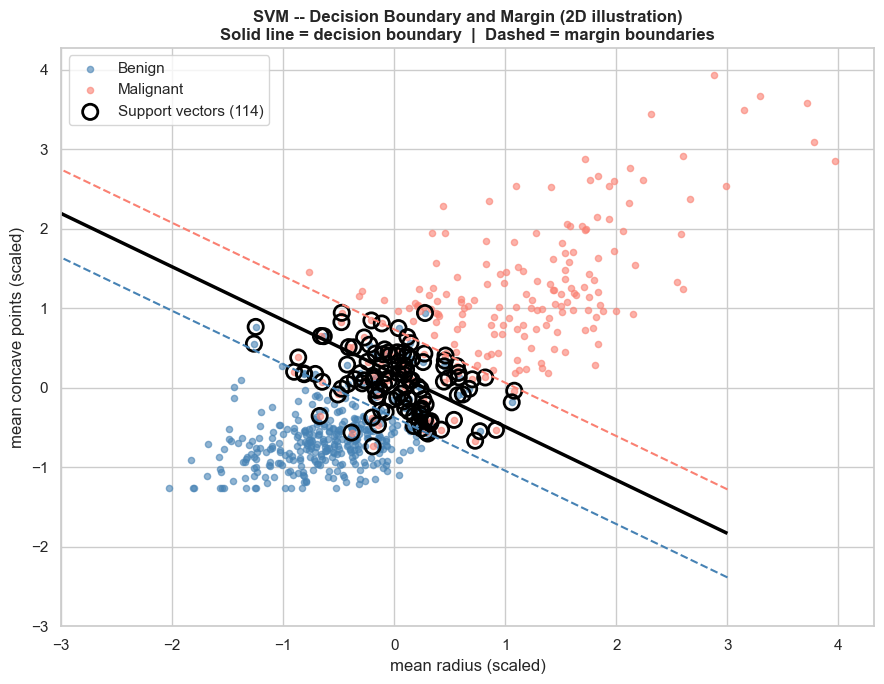

Number of support vectors: 114
  Benign support vectors:    57
  Malignant support vectors: 57

Only these points define the decision boundary.
All other points could be removed and the hyperplane would not change.


In [10]:
# Visualize the margin concept on 2 features (simplified 2D illustration)
from sklearn.svm import SVC

# Use two most separable features for visualization
feat1, feat2 = 'mean radius', 'mean concave points'
X_2d = X[[feat1, feat2]].values

# Scale for SVM
scaler_2d = StandardScaler()
X_2d_sc = scaler_2d.fit_transform(X_2d)

svm_2d = SVC(kernel='linear', C=1.0)
svm_2d.fit(X_2d_sc, y)

# Plot decision boundary and margin
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_2d_sc[y==1, 0], X_2d_sc[y==1, 1],
           color='steelblue', s=20, alpha=0.6, label='Benign')
ax.scatter(X_2d_sc[y==0, 0], X_2d_sc[y==0, 1],
           color='salmon', s=20, alpha=0.6, label='Malignant')

# Decision boundary (Z=0) and margin boundaries (Z=+-1)
ax.contour(xx, yy, Z, levels=[-1, 0, 1],
           linestyles=['--', '-', '--'],
           colors=['salmon', 'black', 'steelblue'],
           linewidths=[1.5, 2.5, 1.5])

# Support vectors
sv = svm_2d.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
           edgecolors='black', linewidths=2, label=f'Support vectors ({len(sv)})')

ax.set_xlabel(f'{feat1} (scaled)')
ax.set_ylabel(f'{feat2} (scaled)')
ax.set_title(
    'SVM -- Decision Boundary and Margin (2D illustration)\n'
    'Solid line = decision boundary  |  Dashed = margin boundaries',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Number of support vectors: {len(sv)}")
print(f"  Benign support vectors:    {svm_2d.n_support_[1]}")
print(f"  Malignant support vectors: {svm_2d.n_support_[0]}")
print()
print("Only these points define the decision boundary.")
print("All other points could be removed and the hyperplane would not change.")

## 4. Why Feature Scaling is Critical for SVM

In [11]:
# This is the most important practical lesson in this notebook
# SVM uses distances between points -- if features are on different scales,
# large-scale features dominate the distance calculation completely

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM WITHOUT scaling
svm_unscaled = SVC(kernel='rbf', C=1.0, random_state=42)
svm_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))

# SVM WITH scaling
svm_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, random_state=42))
])
svm_scaled.fit(X_train, y_train)
acc_scaled = accuracy_score(y_test, svm_scaled.predict(X_test))

print("=" * 45)
print("  Effect of Feature Scaling on SVM")
print("=" * 45)
print(f"  Without StandardScaler: {acc_unscaled:.4f} accuracy")
print(f"  With StandardScaler:    {acc_scaled:.4f} accuracy")
print(f"  Difference:             {acc_scaled - acc_unscaled:+.4f}")
print()
print("Why this happens:")
print("  'mean area' ranges from ~143 to ~2501")
print("  'mean smoothness' ranges from ~0.05 to ~0.16")
print()
print(f"  mean area range:       {X['mean area'].max() - X['mean area'].min():.1f}")
print(f"  mean smoothness range: {X['mean smoothness'].max() - X['mean smoothness'].min():.4f}")
print()
print("Without scaling, mean area completely dominates all distance calculations.")
print("The SVM effectively ignores mean smoothness -- it is numerically invisible.")
print("StandardScaler puts every feature on the same scale, fixing this entirely.")

  Effect of Feature Scaling on SVM
  Without StandardScaler: 0.9298 accuracy
  With StandardScaler:    0.9825 accuracy
  Difference:             +0.0526

Why this happens:
  'mean area' ranges from ~143 to ~2501
  'mean smoothness' ranges from ~0.05 to ~0.16

  mean area range:       2357.5
  mean smoothness range: 0.1108

Without scaling, mean area completely dominates all distance calculations.
The SVM effectively ignores mean smoothness -- it is numerically invisible.
StandardScaler puts every feature on the same scale, fixing this entirely.


## 5. Kernel Comparison -- Linear, RBF, Polynomial

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kernels = {
    'Linear':     SVC(kernel='linear',  C=1.0, probability=True, random_state=42),
    'RBF':        SVC(kernel='rbf',     C=1.0, probability=True, random_state=42),
    'Polynomial': SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42),
    'Sigmoid':    SVC(kernel='sigmoid', C=1.0, probability=True, random_state=42),
}

print(f"{'Kernel':<14} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 36)

kernel_results = {}
for name, model in kernels.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    kernel_results[name] = scores
    print(f"{name:<14} {scores.mean():>12.4f} {scores.std():>8.4f}")

print()
print("RBF (Radial Basis Function) is almost always the best default kernel.")
print("It can learn non-linear boundaries and adapts to the data via the gamma parameter.")
print("Linear kernel is a good choice when you know the data is linearly separable.")

Kernel          CV Accuracy      Std
------------------------------------
Linear               0.9737   0.0222
RBF                  0.9772   0.0163
Polynomial           0.9051   0.0284
Sigmoid              0.9543   0.0086

RBF (Radial Basis Function) is almost always the best default kernel.
It can learn non-linear boundaries and adapts to the data via the gamma parameter.
Linear kernel is a good choice when you know the data is linearly separable.


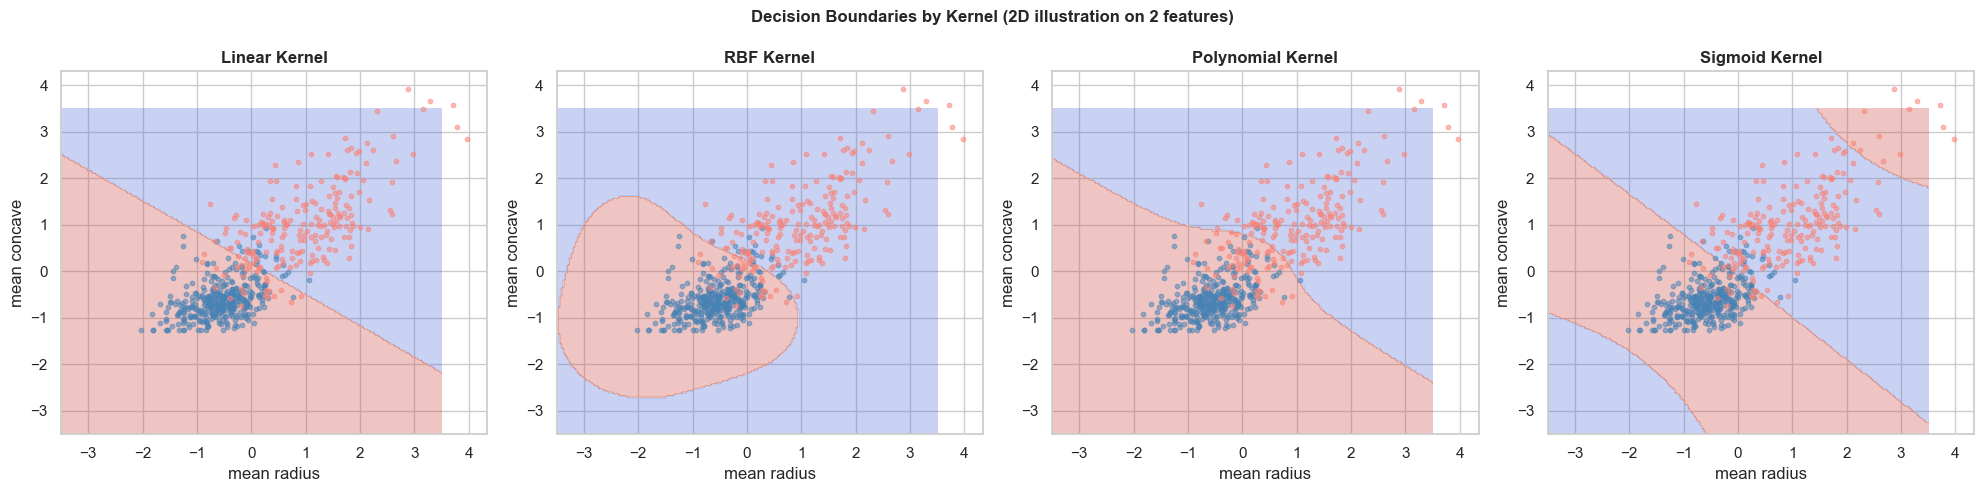

In [13]:
# Visualize kernel decision boundaries on 2D data
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

kernel_list = [
    ('Linear',     SVC(kernel='linear',  C=1.0)),
    ('RBF',        SVC(kernel='rbf',     C=1.0, gamma='scale')),
    ('Polynomial', SVC(kernel='poly',    C=1.0, degree=3)),
    ('Sigmoid',    SVC(kernel='sigmoid', C=1.0)),
]

scaler_viz = StandardScaler()
X_2d_all_sc = scaler_viz.fit_transform(X_2d)

xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-3.5, 3.5, 200))

for ax, (name, model) in zip(axes, kernel_list):
    model.fit(X_2d_all_sc, y)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_2d_all_sc[y==1,0], X_2d_all_sc[y==1,1],
               color='steelblue', s=10, alpha=0.5, label='Benign')
    ax.scatter(X_2d_all_sc[y==0,0], X_2d_all_sc[y==0,1],
               color='salmon',    s=10, alpha=0.5, label='Malignant')
    ax.set_title(f'{name} Kernel', fontweight='bold')
    ax.set_xlabel(feat1[:12])
    ax.set_ylabel(feat2[:12])

plt.suptitle('Decision Boundaries by Kernel (2D illustration on 2 features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning -- C and gamma

In [14]:
# C: regularization -- controls margin width vs misclassification tolerance
# gamma: RBF kernel width -- controls how far influence of a single sample reaches

C_values     = [0.01, 0.1, 1, 10, 100, 1000]
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

print("What C and gamma do:")
print()
print("C (regularization):")
print("  Small C  -- wide margin, more misclassifications allowed -- simpler boundary")
print("  Large C  -- narrow margin, fewer misclassifications -- complex boundary, overfitting risk")
print()
print("gamma (RBF kernel width):")
print("  Small gamma -- wide Gaussian, far-reaching influence -- smoother boundary")
print("  Large gamma -- narrow Gaussian, local influence only -- complex boundary, overfitting risk")
print()
print("Both C and gamma interact -- always tune them together with GridSearchCV")

What C and gamma do:

C (regularization):
  Small C  -- wide margin, more misclassifications allowed -- simpler boundary
  Large C  -- narrow margin, fewer misclassifications -- complex boundary, overfitting risk

gamma (RBF kernel width):
  Small gamma -- wide Gaussian, far-reaching influence -- smoother boundary
  Large gamma -- narrow Gaussian, local influence only -- complex boundary, overfitting risk

Both C and gamma interact -- always tune them together with GridSearchCV


In [15]:
param_grid = {
    'model__C':     [0.01, 0.1, 1, 10, 100, 1000],
    'model__gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'model__kernel':['rbf', 'linear'],
}

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True, random_state=42))
])

total = 6 * 5 * 2
print(f"Grid size: {total} combinations x 5 folds = {total*5} fits")
print("Running GridSearchCV...")

gs = GridSearchCV(
    pipe_svm, param_grid,
    cv=skf, scoring='roc_auc',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV ROC-AUC: {gs.best_score_:.4f}")

Grid size: 60 combinations x 5 folds = 300 fits
Running GridSearchCV...
Best parameters: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.9964


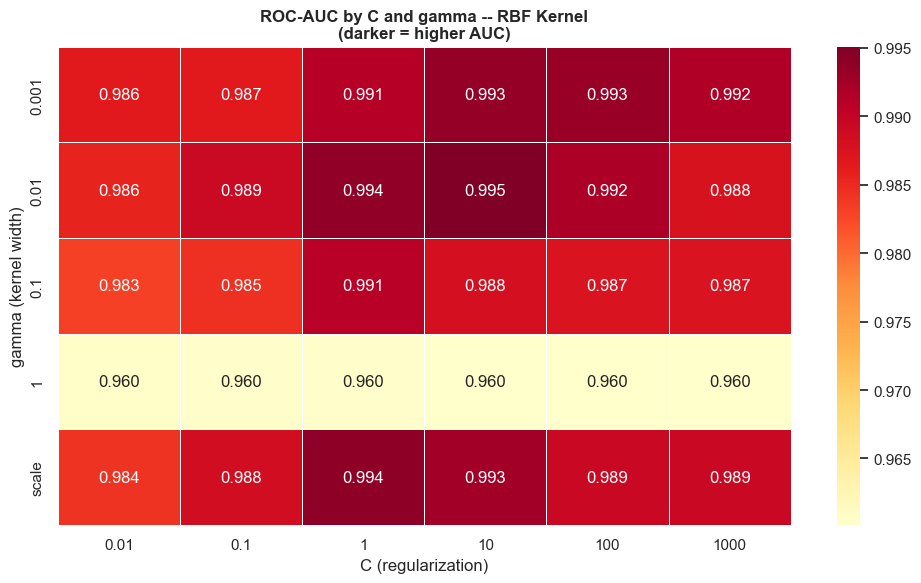

The optimal region shows where margin width and kernel width are balanced.


In [17]:
# Visualize C vs gamma heatmap for RBF kernel
C_range     = [0.01, 0.1, 1, 10, 100, 1000]
gamma_range = [0.001, 0.01, 0.1, 1, 'scale']

scores_matrix = np.zeros((len(gamma_range), len(C_range)))

for i, gamma in enumerate(gamma_range):
    for j, C in enumerate(C_range):
        pipe_tmp = Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(kernel='rbf', C=C, gamma=gamma, random_state=42))
        ])
        score = cross_val_score(pipe_tmp, X_train, y_train,
                                cv=3, scoring='roc_auc').mean()
        scores_matrix[i, j] = score

plt.figure(figsize=(10, 6))
sns.heatmap(scores_matrix,
            xticklabels=C_range,
            yticklabels=gamma_range,
            annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.5)
plt.xlabel('C (regularization)')
plt.ylabel('gamma (kernel width)')
plt.title('ROC-AUC by C and gamma -- RBF Kernel\n(darker = higher AUC)', fontweight='bold')
plt.tight_layout()
plt.show()

print("The optimal region shows where margin width and kernel width are balanced.")

## 7. Final Model Evaluation

In [21]:
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=== Tuned SVM Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['Malignant', 'Benign']))

=== Tuned SVM Results ===
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861
ROC-AUC:   0.9977

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



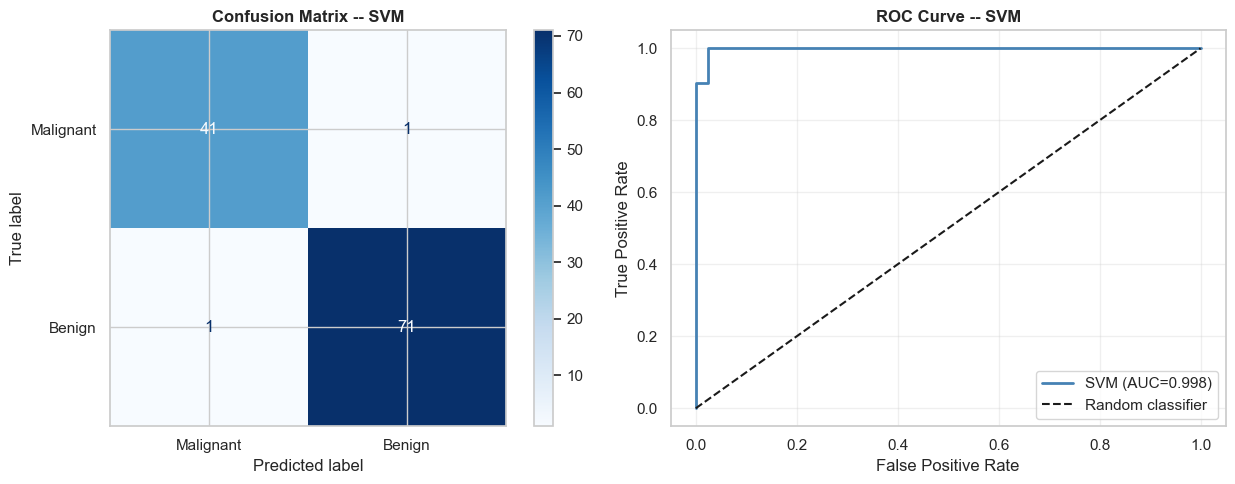

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Malignant', 'Benign'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix -- SVM', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'SVM (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve -- SVM', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# In this medical context, false negatives are critical
# A false negative = malignant tumor classified as benign = missed diagnosis
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Medical context analysis:")
print(f"  True Positives  (benign correctly identified):      {tp}")
print(f"  True Negatives  (malignant correctly identified):   {tn}")
print(f"  False Positives (benign predicted as malignant):    {fp}  -- unnecessary anxiety/biopsy")
print(f"  False Negatives (malignant predicted as benign):    {fn}  -- MISSED DIAGNOSIS")
print()
print("In cancer screening, false negatives are far more dangerous than false positives.")
print("If this were a real deployment decision, recall on the malignant class would")
print("be the primary metric, not overall accuracy.")
print()
print(f"Recall on malignant class: {tn/(tn+fp):.4f}")
print(f"(of all actual malignant cases, the model correctly identified this fraction)")

Medical context analysis:
  True Positives  (benign correctly identified):      71
  True Negatives  (malignant correctly identified):   41
  False Positives (benign predicted as malignant):    1  -- unnecessary anxiety/biopsy
  False Negatives (malignant predicted as benign):    1  -- MISSED DIAGNOSIS

In cancer screening, false negatives are far more dangerous than false positives.
If this were a real deployment decision, recall on the malignant class would
be the primary metric, not overall accuracy.

Recall on malignant class: 0.9762
(of all actual malignant cases, the model correctly identified this fraction)


## 8. Feature Importance via Permutation

SVM does not have built-in feature importances like Decision Trees. Permutation importance measures how much performance drops when a feature is randomly shuffled -- breaking its relationship with the target.

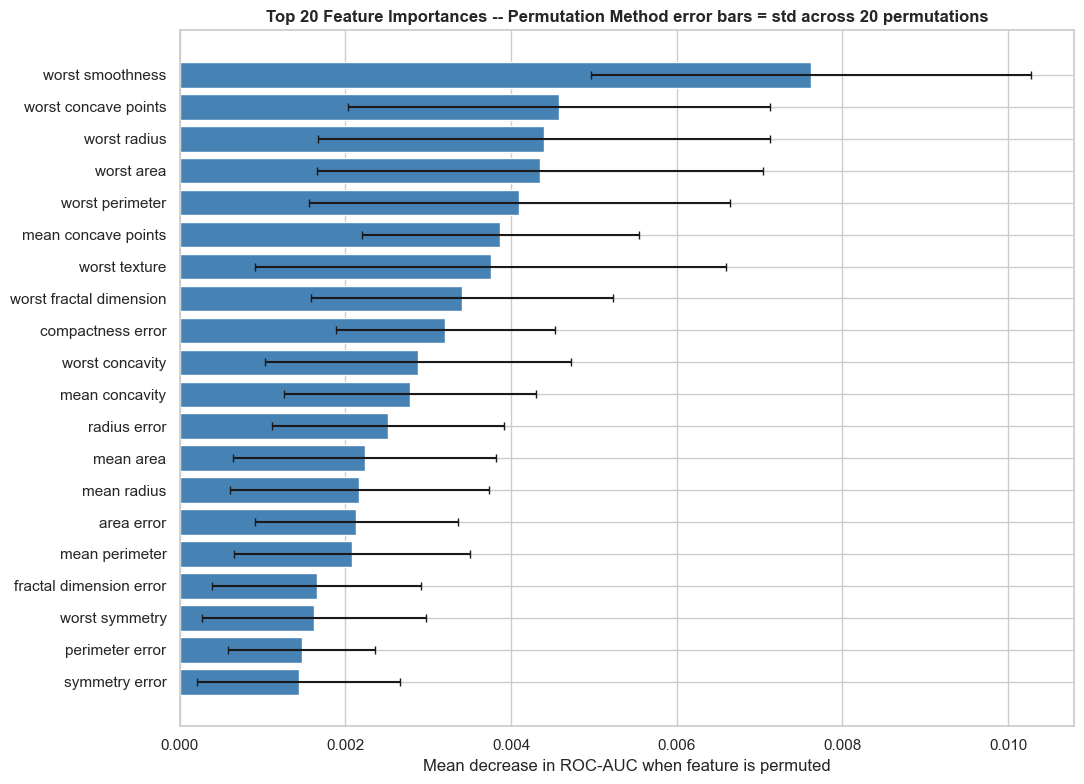

Top 10 most important features for SVM:
                feature  importance      std
       worst smoothness    0.007622 0.002659
   worst concave points    0.004580 0.002547
           worst radius    0.004398 0.002725
             worst area    0.004349 0.002689
        worst perimeter    0.004101 0.002541
    mean concave points    0.003869 0.001670
          worst texture    0.003753 0.002847
worst fractal dimension    0.003406 0.001821
      compactness error    0.003208 0.001323
        worst concavity    0.002877 0.001841


In [24]:
# Fit on full training set first
best_model.fit(X_train, y_train)

perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature':   X.columns,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(11, 8))
plt.barh(perm_df['feature'][:20],
         perm_df['importance'][:20],
         xerr=perm_df['std'][:20],
         color='steelblue', edgecolor='white', capsize=3)
plt.xlabel('Mean decrease in ROC-AUC when feature is permuted')
plt.title('Top 20 Feature Importances -- Permutation Method error bars = std across 20 permutations',   fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 most important features for SVM:")
print(perm_df.head(10)[['feature','importance','std']].to_string(index=False))

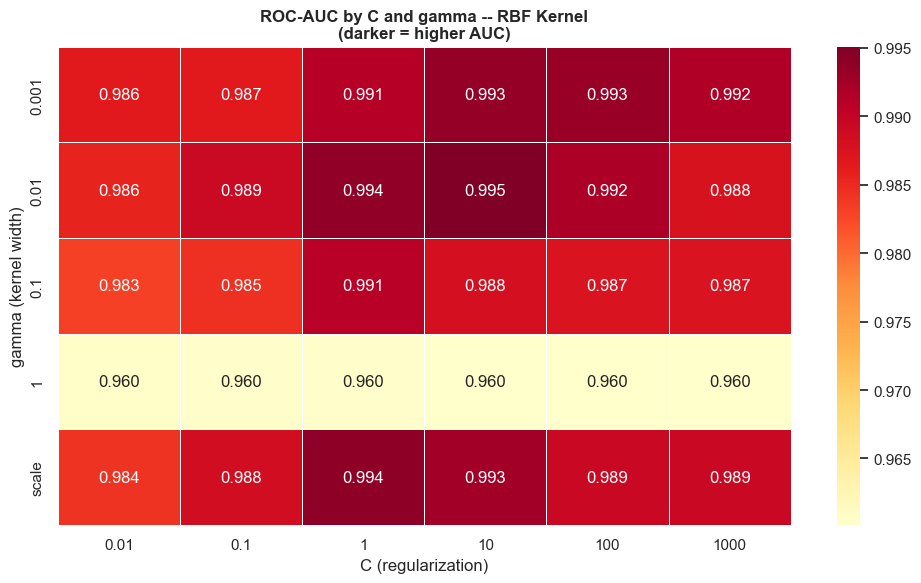

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(scores_matrix,
            xticklabels=C_range,
            yticklabels=gamma_range,
            annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.5)
plt.xlabel('C (regularization)')
plt.ylabel('gamma (kernel width)')
plt.title('ROC-AUC by C and gamma -- RBF Kernel\n(darker = higher AUC)', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Cross-Validation

In [26]:
cv_metrics = {
    'accuracy': cross_val_score(best_model, X, y, cv=skf, scoring='accuracy'),
    'roc_auc':  cross_val_score(best_model, X, y, cv=skf, scoring='roc_auc'),
    'f1':       cross_val_score(best_model, X, y, cv=skf, scoring='f1'),
    'recall':   cross_val_score(best_model, X, y, cv=skf, scoring='recall'),
}

print("5-Fold Stratified Cross-Validation -- SVM:")
print()
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 68)
for metric, scores in cv_metrics.items():
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f}  {folds}")

5-Fold Stratified Cross-Validation -- SVM:

Metric           Mean      Std  Fold scores
--------------------------------------------------------------------
accuracy       0.9807   0.0179  1.0000  0.9474  0.9825  0.9912  0.9823
roc_auc        0.9960   0.0053  1.0000  0.9941  0.9864  1.0000  0.9993
f1             0.9848   0.0142  1.0000  0.9583  0.9863  0.9930  0.9861
recall         0.9916   0.0112  1.0000  0.9718  1.0000  0.9861  1.0000


## 10. SVM vs Logistic Regression vs Decision Tree

In [27]:
# Retrain LR and DT on this dataset for comparison
models_compare = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'SVM (tuned)': best_model,
}

results = {}
for name, model in models_compare.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    cv_auc = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    results[name] = {
        'accuracy':  accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall':    recall_score(y_test, pred),
        'f1':        f1_score(y_test, pred),
        'roc_auc':   roc_auc_score(y_test, prob),
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std':  cv_auc.std(),
        'prob': prob, 'pred': pred
    }

print("=" * 70)
print("  Model Comparison on Breast Cancer Wisconsin Dataset")
print("=" * 70)
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'cv_auc_mean']
print(f"{'Metric':<14}", end="")
for name in results:
    print(f"  {name:>22}", end="")
print()
print("-" * 70)

for metric in metrics_list:
    vals = [results[m][metric] for m in results]
    best = max(vals)
    label = 'CV AUC' if metric == 'cv_auc_mean' else metric
    print(f"{label:<14}", end="")
    for name, val in zip(results, vals):
        flag = " *" if val == best else "  "
        print(f"  {val:>21.4f}{flag}", end="")
    print()

print()
print("* = best score on that metric")

  Model Comparison on Breast Cancer Wisconsin Dataset
Metric             Logistic Regression           Decision Tree             SVM (tuned)
----------------------------------------------------------------------
accuracy                       0.9825 *                 0.9211                   0.9825 *
precision                      0.9861 *                 0.9565                   0.9861 *
recall                         0.9861 *                 0.9167                   0.9861 *
f1                             0.9861 *                 0.9362                   0.9861 *
roc_auc                        0.9954                   0.9163                   0.9977 *
CV AUC                         0.9953                   0.9068                   0.9960 *

* = best score on that metric


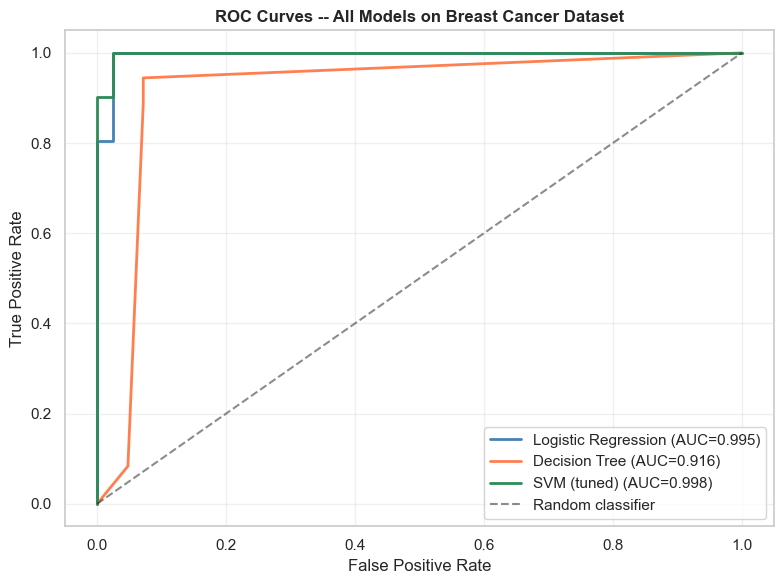

In [28]:
# ROC curves all three models
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc = res['roc_auc']
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- All Models on Breast Cancer Dataset', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

**What SVM does well:**
- Excellent performance in high-dimensional spaces with few samples -- exactly this dataset
- The kernel trick gives it flexibility to learn non-linear boundaries without manually engineering features
- Maximizing the margin makes it more robust than loss-minimizing approaches when data is well-separated
- Once trained, prediction is fast (only support vectors matter)

**What SVM struggles with:**
- Does not scale well to large datasets -- training complexity is between O(n^2) and O(n^3)
- No built-in feature importance -- requires permutation methods or domain knowledge
- Sensitive to feature scale -- StandardScaler is mandatory, not optional
- Probability outputs require an extra calibration step (Platt scaling) and are slower
- Hyperparameter tuning (C and gamma) requires GridSearchCV -- defaults rarely work well

**When to choose SVM over other models:**
- Small to medium dataset (under ~10,000 samples)
- High-dimensional feature space relative to sample count
- You have reason to believe a clear margin exists between classes
- Text classification and image classification (historically strong domain for SVM)

**The key insight from this notebook:**
SVM on this dataset achieves high recall on the malignant class with very few false negatives. In a cancer screening context, that is the metric that matters most. A model with 97% accuracy that misses malignant tumors is clinically worse than one with 94% accuracy that catches almost all of them. Always choose your evaluation metric based on the cost of each error type in the real problem.
